Total Customers Processed: 410
Average Queue Length: 1.14
Average Time in System: 0.28
Server Utilization: 0.66


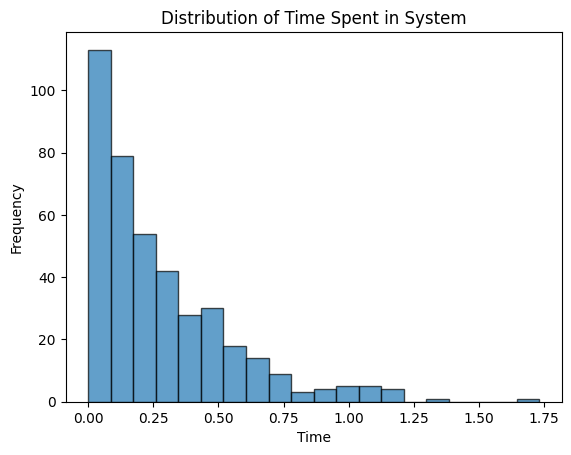

In [ ]:
# m/m/1 queues

import numpy as np
import matplotlib.pyplot as plt

# Parameters
lambda_rate = 3 
mu_rate = 6     
simulation_time = 100  

# Initialize variables
current_time = 0
arrival_time = np.random.exponential(1 / lambda_rate) 
departure_time = float('inf')  
queue = 0 
total_customers = 0 
time_in_system = []  
server_busy_time = 0  

# Simulation
while current_time < simulation_time:
    if arrival_time <= departure_time and arrival_time <= simulation_time:
       
        current_time = arrival_time
        queue += 1
        arrival_time = current_time + np.random.exponential(1 / lambda_rate)
        
        # If server is idle, start serving
        if queue == 1:
            service_time = np.random.exponential(1 / mu_rate)
            departure_time = current_time + service_time
            server_busy_time += service_time
    elif departure_time < arrival_time and departure_time <= simulation_time:
        # A departure event
        current_time = departure_time
        queue -= 1
        total_customers += 1
        time_in_system.append(departure_time - (current_time - np.random.exponential(1 / lambda_rate)))
        
        # If queue is not empty, serve the next customer
        if queue > 0:
            service_time = np.random.exponential(1 / mu_rate)
            departure_time = current_time + service_time
            server_busy_time += service_time
        else:
            departure_time = float('inf')  
    else:
        break

# Metrics
average_queue_length = sum(time_in_system) / simulation_time
average_time_in_system = np.mean(time_in_system)
utilization = server_busy_time / simulation_time

# Print Results
print(f"Total Customers Processed: {total_customers}")
print(f"Average Queue Length: {average_queue_length:.2f}")
print(f"Average Time in System: {average_time_in_system:.2f}")
print(f"Server Utilization: {utilization:.2f}")

# Plot results
plt.hist(time_in_system, bins=20, edgecolor='k', alpha=0.7)
plt.title("Distribution of Time Spent in System")
plt.xlabel("Time")
plt.ylabel("Frequency")
plt.show()




Total Customers Processed: 852
Expected Queue Length: 422.71
Mean System Throughput: 8.53
Mean Server Utilizations: [0.39, 0.4, 0.33, 0.49]
Mean System Response Time: 49.61


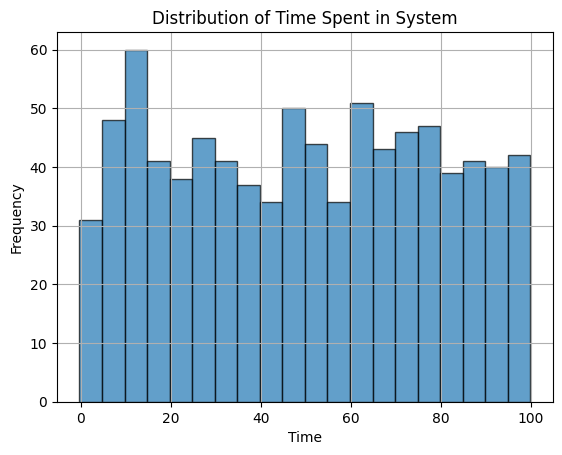

In [ ]:

# M/M/K for K servers
import numpy as np
import matplotlib.pyplot as plt

# Parameters
lambda_rate = 8 
mu_rates = [6, 6, 5,4]  
num_servers = len(mu_rates)  
simulation_time = 100  

# Initialize variables
current_time = 0
arrival_time = np.random.exponential(1 / lambda_rate)  
departure_times = [float('inf')] * num_servers  
queue = 0 
total_customers = 0  
time_in_system = []
server_busy_times = [0] * num_servers  
throughput = 0  

# Simulation loop
while current_time < simulation_time:
    next_departure_time = min(departure_times)
    
    if arrival_time <= next_departure_time and arrival_time <= simulation_time:
        # An arrival event
        current_time = arrival_time
        queue += 1
        arrival_time = current_time + np.random.exponential(1 / lambda_rate)
        
        # Check for an idle server
        idle_servers = [i for i, t in enumerate(departure_times) if t == float('inf')]
        if idle_servers:
            # Choose a random idle server
            chosen_server = np.random.choice(idle_servers)
            service_time = np.random.exponential(1 / mu_rates[chosen_server])
            departure_times[chosen_server] = current_time + service_time
            server_busy_times[chosen_server] += service_time
            queue -= 1
            throughput += 1
    elif next_departure_time <= arrival_time and next_departure_time <= simulation_time:
        # A departure event
        current_time = next_departure_time
        departing_server = departure_times.index(next_departure_time)
        departure_times[departing_server] = float('inf')  # Make the server idle
        total_customers += 1
        time_in_system.append(current_time - np.random.exponential(1 / lambda_rate))
        
        # Serve the next customer in the queue, if any
        if queue > 0:
            service_time = np.random.exponential(1 / mu_rates[departing_server])
            departure_times[departing_server] = current_time + service_time
            server_busy_times[departing_server] += service_time
            queue -= 1
            throughput += 1
    else:
        break

# Metrics
mean_queue_length = sum(time_in_system) / simulation_time
mean_system_throughput = throughput / simulation_time
mean_server_utilizations = [busy_time / simulation_time for busy_time in server_busy_times]
mean_response_time = np.mean(time_in_system)

# Print Results
print(f"Total Customers Processed: {total_customers}")
print(f"Expected Queue Length: {mean_queue_length:.2f}")
print(f"Mean System Throughput: {mean_system_throughput:.2f}")
print(f"Mean Server Utilizations: {[round(u, 2) for u in mean_server_utilizations]}")
print(f"Mean System Response Time: {mean_response_time:.2f}")

# Plot Results
plt.hist(time_in_system, bins=20, edgecolor='k', alpha=0.7)
plt.title("Distribution of Time Spent in System")
plt.xlabel("Time")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()
